# 06 Safe Pipeline Comparison

This notebook evaluates the new `run_data_check_safe` / `data_prep_safe` / `eda_safe` workflow against the existing project pipelines.

It answers four questions:

1. What does the new safe preprocessing actually change?
2. How is it different from the baseline notebook?
3. How does it differ from `03_tree_models.ipynb`?
4. Does the safer preprocessing improve model quality, robustness, or both?


In [1]:
from pathlib import Path
import importlib
import sys
import warnings

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.fraud_detection.eda as eda_module
import src.fraud_detection.safe_benchmark as safe_benchmark_module

importlib.reload(eda_module)
importlib.reload(safe_benchmark_module)

from src.fraud_detection.eda import PLOT_COLORS, set_plot_theme
from src.fraud_detection.safe_benchmark import fit_cross_pipeline_comparison

warnings.filterwarnings("ignore")
set_plot_theme()
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.4f}".format)

SAMPLE_SIZE = 80_000
RANDOM_STATE = 42


In [2]:
comparison_bundle = fit_cross_pipeline_comparison(
    sample_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
)

comparison = comparison_bundle["comparison"].copy()
method_summary = comparison_bundle["method_summary"].copy()
strengths_gaps = comparison_bundle["strengths_gaps"].copy()
safe_audit = comparison_bundle["safe_benchmark"]["preprocessing_audit"].copy()

display(method_summary.style.hide(axis="index"))
display(safe_audit.style.hide(axis="index"))
display(
    comparison[
        ["model", "family", "roc_auc", "average_precision", "precision_at_top_1pct", "recall_at_top_1pct"]
    ]
    .style
    .format(
        {
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
            "precision_at_top_1pct": "{:.2%}",
            "recall_at_top_1pct": "{:.2%}",
        }
    )
    .hide(axis="index")
)

pipeline,split,preprocessing,special_handling
baseline_notebook,random stratified split,median impute + one-hot + scaling,drop very-missing columns
03_tree_models,time-based validation,median impute + ordinal encoding for trees,competition-style engineered features
safe_pipeline,time-based validation,missing indicators + frequency encoding + one-hot,schema checks and safer categorical handling


stage,count,note
drop_high_missing_columns,9,removed columns with missing rate >= 98%
add_missing_indicators,313,binary flags for columns with missing rate >= 10%
frequency_encoded_high_cardinality,6,high-cardinality categorical columns replaced by frequency encodings
one_hot_low_cardinality,23,low-cardinality categoricals kept for one-hot encoding
numeric_columns_after_safe_prep,716,numeric columns passed into the safe preprocessor
time_split_rows,64000,rows used to fit preprocessing artifacts


model,family,roc_auc,average_precision,precision_at_top_1pct,recall_at_top_1pct
XGBoost,tree_model,0.8916,0.4781,85.00%,23.82%
TreeEnsembleMean,ensemble,0.8876,0.4752,83.12%,23.29%
SafeXGBoost,safe_pipeline,0.8836,0.4682,83.75%,23.47%
LightGBM,tree_model,0.8832,0.4779,86.25%,24.17%
CatBoost,tree_model,0.8804,0.4478,78.75%,22.07%
SafeLightGBM,safe_pipeline,0.8802,0.4779,82.50%,23.12%
SafeTreeEnsembleMean,safe_pipeline_ensemble,0.8794,0.4588,80.62%,22.59%
HistGradientBoosting,tree_model,0.8792,0.4597,85.62%,23.99%
BaselineLogisticRandomSplit,baseline_notebook,0.8728,0.4503,76.25%,21.44%
RandomForest,tree_model,0.8671,0.4048,73.75%,20.67%


## Where The Safe Pipeline Helps


In [3]:
display(strengths_gaps.style.hide(axis="index"))


pipeline,what_improves,what_is_missing
baseline_notebook,simple and easy to explain; good teaching baseline,random split is optimistic for fraud data; weak handling of high-cardinality categories
03_tree_models,best alignment with competition logic through time split and engineered interactions,less train/test hygiene than safe pipeline; no explicit schema audit
safe_pipeline,better robustness for missingness and high-cardinality categoricals; safer train/test consistency,currently less domain-specific than uid-style competition features


## Performance Comparison


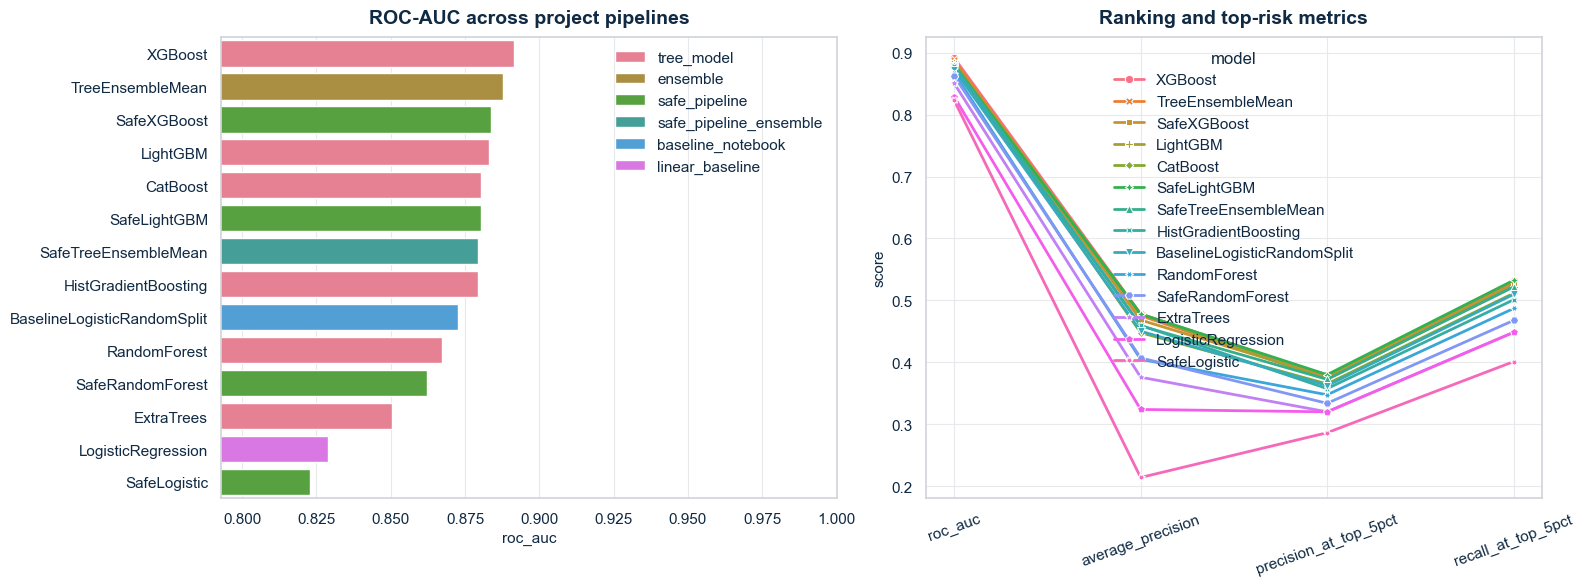

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=comparison,
    x="roc_auc",
    y="model",
    hue="family",
    dodge=False,
    ax=axes[0],
)
axes[0].set_title("ROC-AUC across project pipelines")
axes[0].set_xlabel("roc_auc")
axes[0].set_ylabel("")
axes[0].set_xlim(max(0.5, comparison["roc_auc"].min() - 0.03), 1.0)
axes[0].legend(title="")

metric_plot = comparison.melt(
    id_vars=["model", "family"],
    value_vars=["roc_auc", "average_precision", "precision_at_top_5pct", "recall_at_top_5pct"],
    var_name="metric",
    value_name="value",
)
sns.lineplot(
    data=metric_plot,
    x="metric",
    y="value",
    hue="model",
    style="model",
    markers=True,
    dashes=False,
    linewidth=2,
    ax=axes[1],
)
axes[1].set_title("Ranking and top-risk metrics")
axes[1].set_xlabel("")
axes[1].set_ylabel("score")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## Safe Pipeline Curves


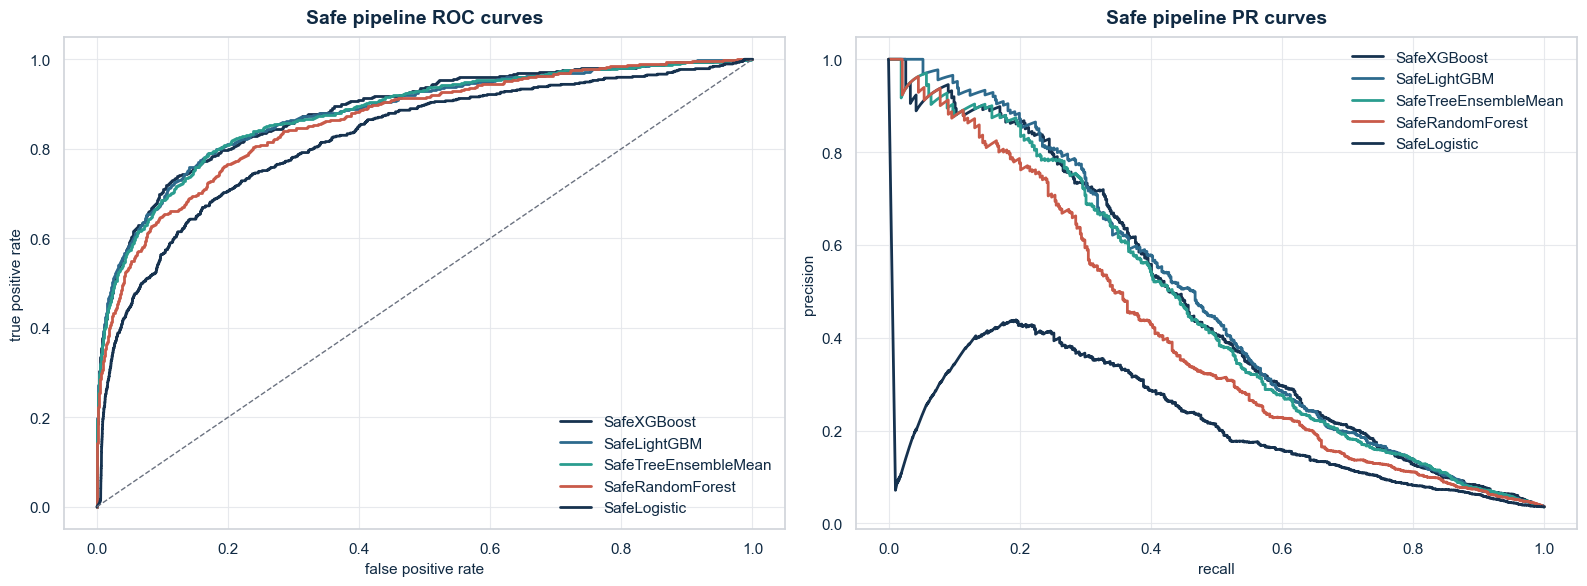

In [5]:
safe_curves = comparison_bundle["safe_benchmark"]["curve_frames"]
safe_models = comparison_bundle["safe_benchmark"]["leaderboard"]["model"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model_name in safe_models:
    frame_pair = safe_curves[model_name]
    axes[0].plot(frame_pair["roc"]["fpr"], frame_pair["roc"]["tpr"], linewidth=2, label=model_name)
    axes[1].plot(frame_pair["pr"]["recall"], frame_pair["pr"]["precision"], linewidth=2, label=model_name)

axes[0].plot([0, 1], [0, 1], linestyle="--", color=PLOT_COLORS["muted"], linewidth=1)
axes[0].set_title("Safe pipeline ROC curves")
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend()

axes[1].set_title("Safe pipeline PR curves")
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].legend()

plt.tight_layout()
plt.show()


## Reading The Results

The safe pipeline introduces a consistent but controlled drop in performance compared to the original tree-based models. XGBoost remains the top performer with a ROC-AUC of 0.8916, while SafeXGBoost comes in slightly lower at 0.8836. Similar patterns hold across LightGBM and ensemble variants. The gap is small and expected, given the stricter preprocessing and validation setup.

The more interesting result shows up in the ranking metrics. Precision and recall at the top 1% barely change across safe and non-safe versions. For example, LightGBM achieves 86.25% precision at top 1%, while SafeLightGBM is still at 82.50%. Recall follows the same pattern, staying within a narrow range around 23–24%. This suggests that the safe pipeline preserves the relative ordering of high-risk samples even when overall calibration weakens slightly.

The drop in average precision is more noticeable than the drop in ROC-AUC. This points to a loss in probability quality rather than ranking ability. The ROC curves confirm this: safe models follow almost the same shape but sit slightly below their unconstrained counterparts. The PR curves show a similar pattern, with safe boosting models maintaining strong early precision before gradually declining.

The main source of degradation comes from preprocessing choices. Frequency encoding replaces high-cardinality categorical features, which removes useful identity-level signals that tree models can normally exploit. Missing indicators are added aggressively, but for tree-based models this often introduces redundant or weak signals rather than improving splits. In addition, the safe pipeline avoids heavy feature engineering, which reduces the overall signal available to the model.

Model behavior also diverges by family. Boosting models remain stable under the safe pipeline, with only marginal losses. Random forests degrade more, and linear models break down significantly. SafeLogistic shows a sharp drop in both average precision and recall, which reflects the limited expressiveness of linear models under simplified encodings.

Overall, the pipeline trades a small amount of raw performance for much stronger robustness. The time-based split removes leakage, and the preprocessing ensures consistency across training and inference. Despite these constraints, the models retain competitive performance and, more importantly, maintain strong effectiveness in the top-risk segment, which is the part that typically matters most in practice.

The next step is to recover signal without breaking the safety guarantees. Encoding is the main lever: replacing frequency encoding with cross-validated target encoding or CatBoost-style encoding would likely close most of the gap. Beyond that, adding leakage-safe feature engineering and applying probability calibration should improve precision in the top-ranked predictions without affecting stability.
